# Homework 9 : Clustering

## **WISIT SUWANNAO 67070501042**

---
## Result for  HW9 : Clustering

**Problem Statement:**
Given data points and initial centroids (in orange) below, use the k-means clustering algorithm
discussed in the lecture to compute new centroids after 3 iterations. Show your work in each
step.

**Data points:** 
`[5, 7], [15, 12], [16, 18], [6, 6], [16, 11], [15, 11], [6, 4], [13, 13], [16, 17], [5, 5], [15, 17], [16, 17], [6, 8], [14, 12], [16, 15]`

**Initial centroids:** 
`C1: [5, 12], C2: [15, 4], C3: [10, 17]`

Initial Centroids:
 [[ 5 12]
 [15  4]
 [10 17]]


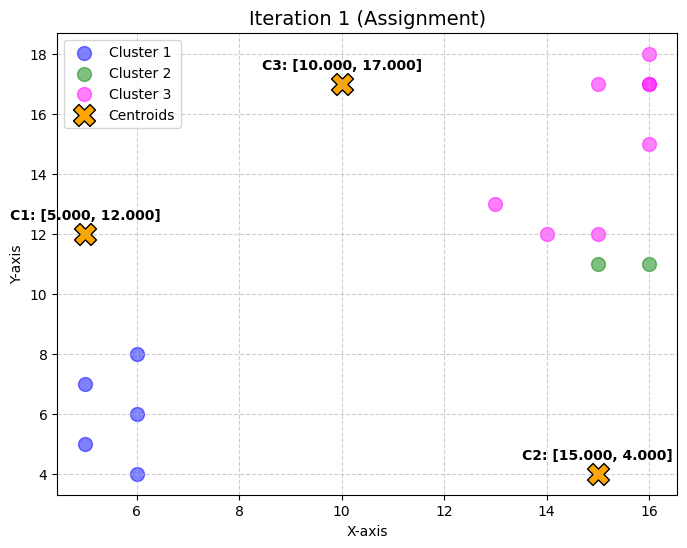


--- Iteration 1 Output ---
Cluster 1 points: [[5, 7], [6, 6], [6, 4], [5, 5], [6, 8]]
New Centroid 1: [5.600, 6.000]
Cluster 2 points: [[16, 11], [15, 11]]
New Centroid 2: [15.500, 11.000]
Cluster 3 points: [[15, 12], [16, 18], [13, 13], [16, 17], [15, 17], [16, 17], [14, 12], [16, 15]]
New Centroid 3: [15.125, 15.125]


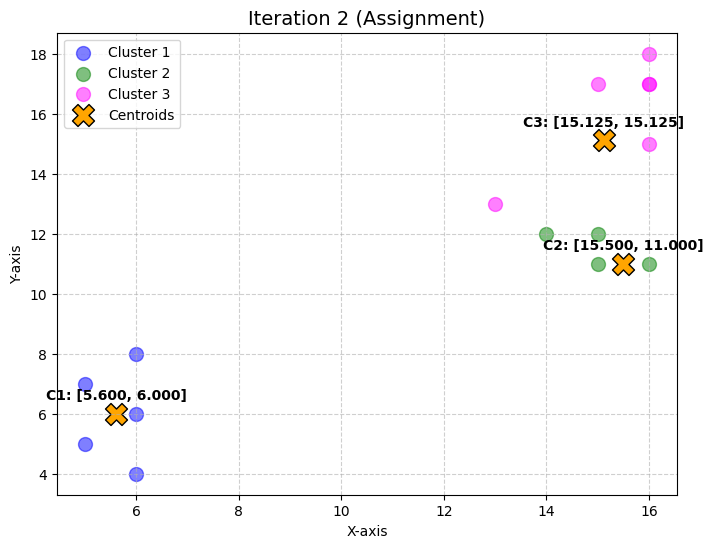


--- Iteration 2 Output ---
Cluster 1 points: [[5, 7], [6, 6], [6, 4], [5, 5], [6, 8]]
New Centroid 1: [5.600, 6.000]
Cluster 2 points: [[15, 12], [16, 11], [15, 11], [14, 12]]
New Centroid 2: [15.000, 11.500]
Cluster 3 points: [[16, 18], [13, 13], [16, 17], [15, 17], [16, 17], [16, 15]]
New Centroid 3: [15.333, 16.167]


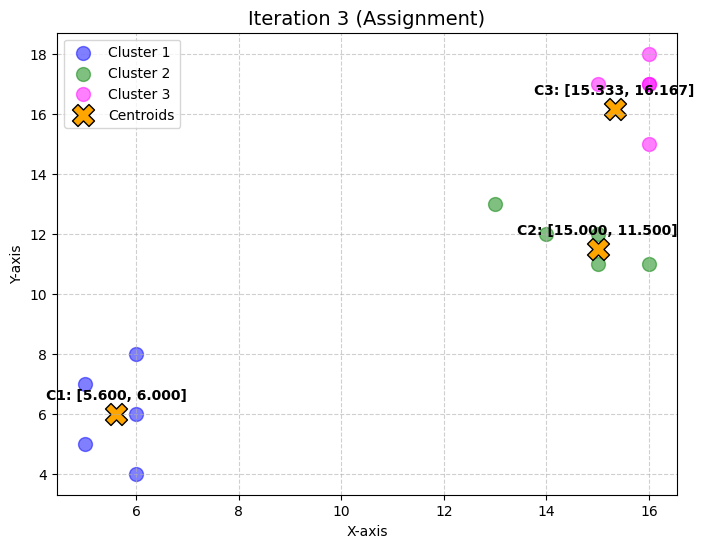


--- Iteration 3 Output ---
Cluster 1 points: [[5, 7], [6, 6], [6, 4], [5, 5], [6, 8]]
New Centroid 1: [5.600, 6.000]
Cluster 2 points: [[15, 12], [16, 11], [15, 11], [13, 13], [14, 12]]
New Centroid 2: [14.600, 11.800]
Cluster 3 points: [[16, 18], [16, 17], [15, 17], [16, 17], [16, 15]]
New Centroid 3: [15.800, 16.800]

Final Result after 3 iterations reached.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define data points and initial centroids
data_points = np.array([
    [5, 7], [15, 12], [16, 18], [6, 6], [16, 11], [15, 11], 
    [6, 4], [13, 13], [16, 17], [5, 5], [15, 17], [16, 17], 
    [6, 8], [14, 12], [16, 15]
])

initial_centroids = np.array([[5.0, 12.0], [15.0, 4.0], [10.0, 17.0]])

# Helper function to plot each iteration
def plot_kmeans_step(data, centroids, labels, iteration, title_suffix=""):
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'magenta']
    
    # Plot points
    for i in range(len(centroids)):
        cluster_points = data[labels == i]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i+1}', s=100, alpha=0.5)
    
    # Plot centroids
    plt.scatter(centroids[:, 0], centroids[:, 1], c='orange', marker='X', s=250, edgecolors='black', label='Centroids')
    
    # Highlight centroid coordinates
    for i, c in enumerate(centroids):
        plt.annotate(f'C{i+1}: [{c[0]:.3f}, {c[1]:.3f}]', (c[0], c[1]), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

    plt.title(f"Iteration {iteration} {title_suffix}", fontsize=14)
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# Run the iterations
current_centroids = initial_centroids.copy()
num_iterations = 3

print(f"Initial Centroids:\n {initial_centroids.astype(int)}")

for i in range(1, num_iterations + 1):
    # Step 1: Assignment
    # Calculate distances (Euclidean square for simplicity)
    distances = np.linalg.norm(data_points[:, np.newaxis] - current_centroids, axis=2)
    labels = np.argmin(distances, axis=1)
    
    # Plot assignment BEFORE recalculating centroids (with old centroids)
    plot_kmeans_step(data_points, current_centroids, labels, i, "(Assignment)")
    
    # Step 2: Update Centroids
    new_centroids = np.array([data_points[labels == j].mean(axis=0) if len(data_points[labels == j]) > 0 else current_centroids[j] for j in range(len(current_centroids))])
    
    print(f"\n--- Iteration {i} Output ---")
    for j in range(len(new_centroids)):
        print(f"Cluster {j+1} points: {data_points[labels == j].tolist()}")
        print(f"New Centroid {j+1}: [{new_centroids[j][0]:.3f}, {new_centroids[j][1]:.3f}]")
    
    current_centroids = new_centroids.copy()
    
    # Optional plot: after recalculating
    # plot_kmeans_step(data_points, current_centroids, labels, i, "(Recalculated)")

print("\nFinal Result after 3 iterations reached.")

### Step-by-Step Calculation (Short Answer Keys from Hand-Written Calculation from HW_9_Clustering.pdf)

#### **Iteration 1**
- **Distance Calculation:** Using Euclidean distance from points to $C_1:[5, 12], C_2:[15, 4], C_3:[10, 17]$.
- **Assignment:**
    - Cluster 1: `[5, 7], [6, 6], [6, 4], [5, 5], [6, 8]`
    - Cluster 2: `[16, 11], [15, 11]`
    - Cluster 3: `[15, 12], [16, 18], [13, 13], [16, 17], [15, 17], [16, 17], [14, 12], [16, 15]`
- **New Centroids:**
    - $C_1 = (5.6, 6.0)$
    - $C_2 = (15.5, 11.0)$
    - $C_3 = (15.125, 15.125)$

#### **Iteration 2**
- **Assignment:**
    - Cluster 1: (No change)
    - Cluster 2: `[15, 12], [16, 11], [15, 11], [14, 12]`
    - Cluster 3: `[16, 18], [13, 13], [16, 17], [15, 17], [16, 17], [16, 15]`
- **New Centroids:**
    - $C_1 = (5.6, 6.0)$
    - $C_2 = (15.0, 11.5)$
    - $C_3 = (15.33, 16.17)$

#### **Iteration 3**
- **Assignment:**
    - Cluster 1: (No change)
    - Cluster 2: `[15, 12], [16, 11], [15, 11], [14, 12], [13, 13]`
    - Cluster 3: `[16, 18], [16, 17], [15, 17], [16, 17], [16, 15]`
- **Final Centroids after 3 Iterations:**
    - $C_1 = (5.6, 6.0)$
    - $C_2 = (14.6, 11.8)$
    - $C_3 = (15.8, 16.8)$